In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
product_sales = pd.read_csv("../content/sales_integrated.csv")

print("Dataset shape:", product_sales.shape)

Dataset shape: (130402, 55)


In [3]:
print(product_sales.head())
print("\nColumns:")
print(product_sales.columns.tolist())

       so_id  line_number product_id  quantity  unit_price  gst_rate  \
0  SO-990591            1       P018        19       11300        28   
1  SO-990591            2       P026         2         310        18   
2  SO-990591            3       P026         3         310        18   
3  SO-990591            4       P013         9        1450        18   
4  SO-990591            5       P004         3       39800        28   

   line_total  gst_amount  line_grand_total customer_id  ... pincode region  \
0      214700     60116.0          274816.0       C0070  ...  784913   West   
1         620       111.6             731.6       C0070  ...  784913   West   
2         930       167.4            1097.4       C0070  ...  784913   West   
3       13050      2349.0           15399.0       C0070  ...  784913   West   
4      119400     33432.0          152832.0       C0070  ...  784913   West   

  branch_id_customer credit_limit current_balance  payment_terms_customer  \
0             A

Check Required Columns

In [4]:
required_columns = [
    "branch_id",
    "product_id",
    "product_name",
    "quantity",
    "line_total",
    "customer_id",
    "order_date"
]

missing_columns = [
    col for col in required_columns
    if col not in product_sales.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


### **DATA PREPARATION**

In [5]:
# Create Analysis Copy
week7_data = product_sales.copy()

print("Week 7 dataset shape:", week7_data.shape)

Week 7 dataset shape: (130402, 55)


Convert Numeric Columns

In [6]:
numeric_columns = [
    "quantity",
    "line_total",
    "unit_price",
    "unit_cost",
    "margin_percentage"
]

for col in numeric_columns:
    if col in week7_data.columns:
        week7_data[col] = pd.to_numeric(
            week7_data[col],
            errors="coerce"
        )

print(week7_data[numeric_columns].dtypes)

quantity               int64
line_total             int64
unit_price             int64
unit_cost              int64
margin_percentage    float64
dtype: object


Convert Order Dates

In [7]:
week7_data["order_date"] = pd.to_datetime(
    week7_data["order_date"],
    errors="coerce"
)

print(week7_data["order_date"].min())
print(week7_data["order_date"].max())

2019-01-01 00:00:00
2024-12-31 00:00:00


Check Missing Values

In [8]:
missing_summary = (
    week7_data[required_columns]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary)

branch_id       0
product_id      0
product_name    0
quantity        0
line_total      0
customer_id     0
order_date      0
dtype: int64


Check Duplicates

In [9]:
print("Duplicate rows:", week7_data.duplicated().sum())

Duplicate rows: 0


In [10]:
week7_data.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
so_id,130402,20000,SO-467856,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
line_number,130402.0,NaN,NaN,NaN,4.670672,1.0,2.0,4.0,7.0,12.0,2.924837
product_id,130402,30,P011,4462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,130402.0,NaN,NaN,NaN,10.494732,1.0,6.0,10.0,15.0,20.0,5.764858
unit_price,130402.0,NaN,NaN,NaN,18528.782687,310.0,1450.0,10200.0,24500.0,119000.0,25971.041338
gst_rate,130402.0,NaN,NaN,NaN,23.653748,18.0,18.0,28.0,28.0,28.0,4.957096
line_total,130402.0,NaN,NaN,NaN,195145.722918,310.0,12240.0,67600.0,220500.0,2380000.0,329936.762081
gst_amount,130402.0,NaN,NaN,NaN,53506.556616,55.8,2349.0,15820.0,61740.0,666400.0,92810.616023
line_grand_total,130402.0,NaN,NaN,NaN,248652.279534,365.8,14464.0,84252.0,282240.0,3046400.0,422713.784043
customer_id,130402,500,C0288,447,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Product Performance Analysis**

In [11]:
# Create Product Performance Dataset
product_performance = (
    week7_data
    .groupby(["product_id", "product_name"])
    .agg(
        total_units_sold=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        total_orders=("so_id", "nunique"),
        warehouses_served=("branch_id", "nunique"),
        customers_served=("customer_id", "nunique")
    )
    .reset_index()
)

product_performance.head()

,product_id,product_name,total_units_sold,total_revenue,total_orders,warehouses_served,customers_served
0,P001,Hydraulic Pump HP-300,45389,1112030500,3854,6,500
1,P002,Engine Oil Filter OF-90,45342,32646240,3861,6,500
2,P003,Air Filter AF-120,45684,57105000,3895,6,500
3,P004,Track Chain TC-45,45575,1813885000,3781,6,500
4,P005,Fuel Injector FI-220,45026,380469700,3840,6,500


Calculate Average Revenue per Order

In [12]:
product_performance["average_revenue_per_order"] = (
    product_performance["total_revenue"] /
    product_performance["total_orders"]
)

product_performance.head()

,product_id,product_name,total_units_sold,total_revenue,total_orders,warehouses_served,customers_served,average_revenue_per_order
0,P001,Hydraulic Pump HP-300,45389,1112030500,3854,6,500,288539.309808
1,P002,Engine Oil Filter OF-90,45342,32646240,3861,6,500,8455.384615
2,P003,Air Filter AF-120,45684,57105000,3895,6,500,14661.103979
3,P004,Track Chain TC-45,45575,1813885000,3781,6,500,479736.842105
4,P005,Fuel Injector FI-220,45026,380469700,3840,6,500,99080.651042


Calculate Revenue Share

In [13]:
total_revenue = product_performance["total_revenue"].sum()

product_performance["revenue_share_percentage"] = (
    product_performance["total_revenue"] /
    total_revenue * 100
)

product_performance.head()

,product_id,product_name,total_units_sold,total_revenue,total_orders,warehouses_served,customers_served,average_revenue_per_order,revenue_share_percentage
0,P001,Hydraulic Pump HP-300,45389,1112030500,3854,6,500,288539.309808,4.369919
1,P002,Engine Oil Filter OF-90,45342,32646240,3861,6,500,8455.384615,0.128289
2,P003,Air Filter AF-120,45684,57105000,3895,6,500,14661.103979,0.224404
3,P004,Track Chain TC-45,45575,1813885000,3781,6,500,479736.842105,7.127980
4,P005,Fuel Injector FI-220,45026,380469700,3840,6,500,99080.651042,1.495123


Calculate Unit Share

In [14]:
total_units = product_performance["total_units_sold"].sum()

product_performance["unit_share_percentage"] = (
    product_performance["total_units_sold"] /
    total_units * 100
)

Sort Products by Revenue

In [15]:
top_products_revenue = product_performance.sort_values(
    "total_revenue",
    ascending=False
)

top_products_revenue.head(10)

,product_id,product_name,total_units_sold,total_revenue,total_orders,warehouses_served,customers_served,average_revenue_per_order,revenue_share_percentage,unit_share_percentage
14,P015,Engine Block EB-600,45222,5381418000,3773,6,499,1.426297e+06,21.147228,3.304412
13,P014,Transmission Assembly TA-800,45035,3760422500,3838,6,500,9.797870e+05,14.777241,3.290748
20,P021,Boom Cylinder BC-400,46364,2142016800,3873,6,500,5.530640e+05,8.417431,3.387859
18,P019,Swing Motor SWM-350,45971,1829645800,3849,6,499,4.753561e+05,7.189915,3.359142
3,P004,Track Chain TC-45,45575,1813885000,3781,6,500,4.797368e+05,7.127980,3.330206
9,P010,Turbocharger TB-900,46964,1639043600,3933,6,500,4.167413e+05,6.440910,3.431701
10,P011,Hydraulic Cylinder HC-200,46612,1286491200,3982,6,500,3.230766e+05,5.055493,3.405980
0,P001,Hydraulic Pump HP-300,45389,1112030500,3854,6,500,2.885393e+05,4.369919,3.316615
29,P030,Fuel Pump FP-350,45897,1005144300,3856,6,500,2.606702e+05,3.949891,3.353735
21,P022,Control Valve CV-75,45819,774341100,3892,6,500,1.989571e+05,3.042909,3.348035


Sort Products by Units Sold

In [16]:
top_products_units = product_performance.sort_values(
    "total_units_sold",
    ascending=False
)

top_products_units.head(10)

,product_id,product_name,total_units_sold,total_revenue,total_orders,warehouses_served,customers_served,average_revenue_per_order,revenue_share_percentage,unit_share_percentage
28,P029,Pressure Sensor PS-90,47066,185910700,3882,6,500,47890.443071,0.730569,3.439155
9,P010,Turbocharger TB-900,46964,1639043600,3933,6,500,416741.317061,6.440910,3.431701
5,P006,Alternator ALT-500,46731,523387200,3936,6,500,132974.390244,2.056742,3.414676
10,P011,Hydraulic Cylinder HC-200,46612,1286491200,3982,6,500,323076.644902,5.055493,3.405980
6,P007,Hydraulic Hose HH-60,46468,67378600,3906,6,499,17250.025602,0.264776,3.395458
20,P021,Boom Cylinder BC-400,46364,2142016800,3873,6,500,553063.981410,8.417431,3.387859
15,P016,Radiator RD-250,46306,472321200,3934,6,500,120061.311642,1.856069,3.383621
27,P028,Light Assembly LA-18,46164,103869000,3917,6,500,26517.487873,0.408171,3.373245
11,P012,Brake Pad BP-40,45972,112631400,3883,6,500,29006.283801,0.442605,3.359215
18,P019,Swing Motor SWM-350,45971,1829645800,3849,6,499,475356.144453,7.189915,3.359142


### **PRODUCT PERFORMANCE SCORING**

Create Revenue Score

In [17]:
product_performance["revenue_score"] = (
    product_performance["total_revenue"]
    / product_performance["total_revenue"].max()
    * 100
)

Create Unit Sales Score

In [18]:
product_performance["unit_score"] = (
    product_performance["total_units_sold"]
    / product_performance["total_units_sold"].max()
    * 100
)

Create Order Score

In [19]:
product_performance["order_score"] = (
    product_performance["total_orders"]
    / product_performance["total_orders"].max()
    * 100
)

### **Create Product Performance Score**<br>
50% revenue<br>
30% units sold<br>
20% orders

In [20]:
product_performance["product_performance_score"] = (
    product_performance["revenue_score"] * 0.50 +
    product_performance["unit_score"] * 0.30 +
    product_performance["order_score"] * 0.20
)

product_performance[
    [
        "product_id",
        "product_name",
        "product_performance_score"
    ]
].sort_values(
    "product_performance_score",
    ascending=False
).head(10)

,product_id,product_name,product_performance_score
14,P015,Engine Block EB-600,97.774905
13,P014,Transmission Assembly TA-800,82.921136
20,P021,Boom Cylinder BC-400,68.907053
18,P019,Swing Motor SWM-350,65.633700
9,P010,Turbocharger TB-900,64.917611
3,P004,Track Chain TC-45,64.893315
10,P011,Hydraulic Cylinder HC-200,61.663707
0,P001,Hydraulic Pump HP-300,58.620315
29,P030,Fuel Pump FP-350,57.961057
21,P022,Control Valve CV-75,55.947707


Classify Product Performance

In [51]:
# Calculate performance score thresholds
high_threshold = product_performance[
    "product_performance_score"
].quantile(0.75)

low_threshold = product_performance[
    "product_performance_score"
].quantile(0.25)

print("High-performance threshold:", round(high_threshold, 2))
print("Low-performance threshold:", round(low_threshold, 2))

High-performance threshold: 58.46
Low-performance threshold: 49.37


In [52]:
product_performance["performance_category"] = np.select(
    [
        product_performance["product_performance_score"] >= high_threshold,
        product_performance["product_performance_score"] <= low_threshold
    ],
    [
        "High Performance",
        "Low Performance"
    ],
    default="Medium Performance"
)

product_performance[
    "performance_category"
].value_counts()

,count
performance_category,
Medium Performance,14
High Performance,8
Low Performance,8


In [53]:
# Check the actual products
product_performance[
    [
        "product_id",
        "product_name",
        "product_performance_score",
        "performance_category"
    ]
].sort_values(
    "product_performance_score",
    ascending=False
)

,product_id,product_name,product_performance_score,performance_category
14,P015,Engine Block EB-600,97.774905,High Performance
13,P014,Transmission Assembly TA-800,82.921136,High Performance
20,P021,Boom Cylinder BC-400,68.907053,High Performance
18,P019,Swing Motor SWM-350,65.633700,High Performance
9,P010,Turbocharger TB-900,64.917611,High Performance
3,P004,Track Chain TC-45,64.893315,High Performance
10,P011,Hydraulic Cylinder HC-200,61.663707,High Performance
0,P001,Hydraulic Pump HP-300,58.620315,High Performance
29,P030,Fuel Pump FP-350,57.961057,Medium Performance
21,P022,Control Valve CV-75,55.947707,Medium Performance


### **Warehouse Performance**<br>
Create Warehouse Performance Dataset

In [22]:
warehouse_performance = (
    week7_data
    .groupby("branch_id")
    .agg(
        total_orders=("so_id", "nunique"),
        total_units=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        products_handled=("product_id", "nunique"),
        customers_served=("customer_id", "nunique")
    )
    .reset_index()
)

warehouse_performance

,branch_id,total_orders,total_units,total_revenue,products_handled,customers_served
0,AHM001,3446,236347,4407886140,30,88
1,CHN001,4067,280446,5192125100,30,102
2,DEL001,2953,204734,3865954470,30,71
3,HYD001,2768,189163,3452672510,30,68
4,KOL001,3794,256095,4787656160,30,96
5,PUN001,2972,201749,3741098180,30,75


Calculate Average Order Value

In [23]:
warehouse_performance["average_order_value"] = (
    warehouse_performance["total_revenue"] /
    warehouse_performance["total_orders"]
)

Calculate Average Units per Order

In [24]:
warehouse_performance["average_units_per_order"] = (
    warehouse_performance["total_units"] /
    warehouse_performance["total_orders"]
)

Calculate Warehouse Revenue Share

In [25]:
warehouse_total_revenue = (
    warehouse_performance["total_revenue"].sum()
)

warehouse_performance["revenue_share_percentage"] = (
    warehouse_performance["total_revenue"] /
    warehouse_total_revenue * 100
)

### **WAREHOUSE PERFORMANCE SCORING**<br>
Create Warehouse Revenue Score

In [26]:
warehouse_performance["revenue_score"] = (
    warehouse_performance["total_revenue"] /
    warehouse_performance["total_revenue"].max()
    * 100
)

Create Warehouse Order Score

In [27]:
warehouse_performance["order_score"] = (
    warehouse_performance["total_orders"] /
    warehouse_performance["total_orders"].max()
    * 100
)

Create Warehouse Unit Score

In [28]:
warehouse_performance["unit_score"] = (
    warehouse_performance["total_units"] /
    warehouse_performance["total_units"].max()
    * 100
)

Create Product Variety Score

In [29]:
warehouse_performance["product_variety_score"] = (
    warehouse_performance["products_handled"] /
    warehouse_performance["products_handled"].max()
    * 100
)

### **Calculate Overall Warehouse Performance Score**<br>

In [58]:
# Calculate performance score thresholds
high_threshold = warehouse_performance[
    "warehouse_performance_score"
].quantile(0.75)

low_threshold = warehouse_performance[
    "warehouse_performance_score"
].quantile(0.25)

print("High-performance threshold:", round(high_threshold, 2))
print("Low-performance threshold:", round(low_threshold, 2))

High-performance threshold: 91.33
Low-performance threshold: 75.35


Classify Warehouse Performance

In [59]:
warehouse_performance["performance_category"] = np.select(
    [
        warehouse_performance["warehouse_performance_score"] >= high_threshold,
        warehouse_performance["warehouse_performance_score"] <= low_threshold
    ],
    [
        "High Performance",
        "Low Performance"
    ],
    default="Medium Performance"
)

print(
    warehouse_performance[
        "performance_category"
    ].value_counts()
)

performance_category
Medium Performance    2
High Performance      2
Low Performance       2
Name: count, dtype: int64


### **PRODUCT–WAREHOUSE ALIGNMENT**

Create Product–Warehouse Dataset

In [32]:
product_warehouse = (
    week7_data
    .groupby(
        ["branch_id", "product_id", "product_name"]
    )
    .agg(
        total_units=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        total_orders=("so_id", "nunique"),
        customers_served=("customer_id", "nunique")
    )
    .reset_index()
)

product_warehouse.head()

,branch_id,product_id,product_name,total_units,total_revenue,total_orders,customers_served
0,AHM001,P001,Hydraulic Pump HP-300,7642,187229000,644,88
1,AHM001,P002,Engine Oil Filter OF-90,7772,5595840,663,88
2,AHM001,P003,Air Filter AF-120,8090,10112500,682,88
3,AHM001,P004,Track Chain TC-45,8107,322658600,670,88
4,AHM001,P005,Fuel Injector FI-220,7979,67422550,677,88


### **Calculate Revenue Share Within Warehouse**

In [33]:
warehouse_product_revenue = (
    product_warehouse
    .groupby("branch_id")["total_revenue"]
    .transform("sum")
)

product_warehouse["warehouse_revenue_share"] = (
    product_warehouse["total_revenue"] /
    warehouse_product_revenue * 100
)

### **Find Top Product in Each Warehouse**

In [34]:
top_product_by_warehouse = (
    product_warehouse
    .sort_values(
        ["branch_id", "total_revenue"],
        ascending=[True, False]
    )
    .groupby("branch_id")
    .head(1)
)

top_product_by_warehouse

,branch_id,product_id,product_name,total_units,total_revenue,total_orders,customers_served,warehouse_revenue_share
14,AHM001,P015,Engine Block EB-600,8164,971516000,675,88,22.040406
44,CHN001,P015,Engine Block EB-600,8869,1055411000,766,102,20.327149
74,DEL001,P015,Engine Block EB-600,6921,823599000,578,71,21.303898
104,HYD001,P015,Engine Block EB-600,6054,720426000,502,67,20.865750
134,KOL001,P015,Engine Block EB-600,8611,1024709000,710,96,21.403145
164,PUN001,P015,Engine Block EB-600,6603,785757000,542,75,21.003378


### **Find Top Product–Warehouse Combinations**

In [35]:
top_product_warehouse = product_warehouse.sort_values(
    "total_revenue",
    ascending=False
)

top_product_warehouse.head(20)

,branch_id,product_id,product_name,total_units,total_revenue,total_orders,customers_served,warehouse_revenue_share
44,CHN001,P015,Engine Block EB-600,8869,1055411000,766,102,20.327149
134,KOL001,P015,Engine Block EB-600,8611,1024709000,710,96,21.403145
14,AHM001,P015,Engine Block EB-600,8164,971516000,675,88,22.040406
74,DEL001,P015,Engine Block EB-600,6921,823599000,578,71,21.303898
43,CHN001,P014,Transmission Assembly TA-800,9557,798009500,801,102,15.369612
164,PUN001,P015,Engine Block EB-600,6603,785757000,542,75,21.003378
104,HYD001,P015,Engine Block EB-600,6054,720426000,502,67,20.865750
133,KOL001,P014,Transmission Assembly TA-800,8071,673928500,704,96,14.076376
13,AHM001,P014,Transmission Assembly TA-800,7593,634015500,646,88,14.383663
73,DEL001,P014,Transmission Assembly TA-800,7198,601033000,598,71,15.546820


### **Find Products Served by Multiple Warehouses**

In [36]:
product_distribution = (
    product_warehouse
    .groupby(["product_id", "product_name"])
    .agg(
        warehouses_served=("branch_id", "nunique"),
        total_units=("total_units", "sum"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

product_distribution.sort_values(
    "warehouses_served",
    ascending=False
).head(10)

,product_id,product_name,warehouses_served,total_units,total_revenue
0,P001,Hydraulic Pump HP-300,6,45389,1112030500
1,P002,Engine Oil Filter OF-90,6,45342,32646240
2,P003,Air Filter AF-120,6,45684,57105000
3,P004,Track Chain TC-45,6,45575,1813885000
4,P005,Fuel Injector FI-220,6,45026,380469700
5,P006,Alternator ALT-500,6,46731,523387200
6,P007,Hydraulic Hose HH-60,6,46468,67378600
7,P008,Bucket Tooth BT-10,6,45376,26318080
8,P009,Starter Motor SM-700,6,44946,669695400
9,P010,Turbocharger TB-900,6,46964,1639043600


### **Identify Products Concentrated in One Warehouse**

In [37]:
product_distribution["warehouse_concentration"] = np.where(
    product_distribution["warehouses_served"] == 1,
    "Single Warehouse",
    "Multiple Warehouses"
)

product_distribution[
    "warehouse_concentration"
].value_counts()

,count
warehouse_concentration,
Multiple Warehouses,30


### **PRODUCT–WAREHOUSE PERFORMANCE**

### **Calculate Combination Performance Score**

In [38]:
product_warehouse["revenue_score"] = (
    product_warehouse["total_revenue"] /
    product_warehouse["total_revenue"].max()
    * 100
)

product_warehouse["unit_score"] = (
    product_warehouse["total_units"] /
    product_warehouse["total_units"].max()
    * 100
)

product_warehouse["order_score"] = (
    product_warehouse["total_orders"] /
    product_warehouse["total_orders"].max()
    * 100
)

### **Create Alignment Score**

In [39]:
product_warehouse["alignment_score"] = (
    product_warehouse["revenue_score"] * 0.50 +
    product_warehouse["unit_score"] * 0.30 +
    product_warehouse["order_score"] * 0.20
)

product_warehouse.sort_values(
    "alignment_score",
    ascending=False
).head(20)

,branch_id,product_id,product_name,total_units,total_revenue,total_orders,customers_served,warehouse_revenue_share,revenue_score,unit_score,order_score,alignment_score
44,CHN001,P015,Engine Block EB-600,8869,1055411000,766,102,20.327149,100.000000,90.509236,92.289157,95.610602
134,KOL001,P015,Engine Block EB-600,8611,1024709000,710,96,21.403145,97.090991,87.876314,85.542169,92.016823
14,AHM001,P015,Engine Block EB-600,8164,971516000,675,88,22.040406,92.050964,83.314624,81.325301,87.284929
43,CHN001,P014,Transmission Assembly TA-800,9557,798009500,801,102,15.369612,75.611255,97.530360,96.506024,86.365940
74,DEL001,P015,Engine Block EB-600,6921,823599000,578,71,21.303898,78.035855,70.629656,69.638554,74.134535
133,KOL001,P014,Transmission Assembly TA-800,8071,673928500,704,96,14.076376,63.854603,82.365548,84.819277,73.600821
164,PUN001,P015,Engine Block EB-600,6603,785757000,542,75,21.003378,74.450333,67.384427,65.301205,70.500735
13,AHM001,P014,Transmission Assembly TA-800,7593,634015500,646,88,14.383663,60.072853,77.487499,77.831325,68.848941
50,CHN001,P021,Boom Cylinder BC-400,9435,435897000,789,102,8.395349,41.301161,96.285335,95.060241,68.548229
48,CHN001,P019,Swing Motor SWM-350,9351,372169800,780,102,7.167967,35.263021,95.428105,93.975904,65.055123


### **PERFORMANCE COMPARISON**

### **Compare Product Performance Categories**

In [40]:
product_category_summary = (
    product_performance
    .groupby("performance_category")
    .agg(
        products=("product_id", "nunique"),
        total_units=("total_units_sold", "sum"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

product_category_summary

,performance_category,products,total_units,total_revenue
0,High Performance,2,90257,9141840500
1,Medium Performance,28,1278277,16305552060


### **Compare Warehouse Performance Categories**

In [41]:
warehouse_category_summary = (
    warehouse_performance
    .groupby("performance_category")
    .agg(
        warehouses=("branch_id", "nunique"),
        total_orders=("total_orders", "sum"),
        total_units=("total_units", "sum"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

warehouse_category_summary

,performance_category,warehouses,total_orders,total_units,total_revenue
0,High Performance,6,20000,1368534,25447392560


### **VISUALISATIONS**

### **Top Products by Revenue**

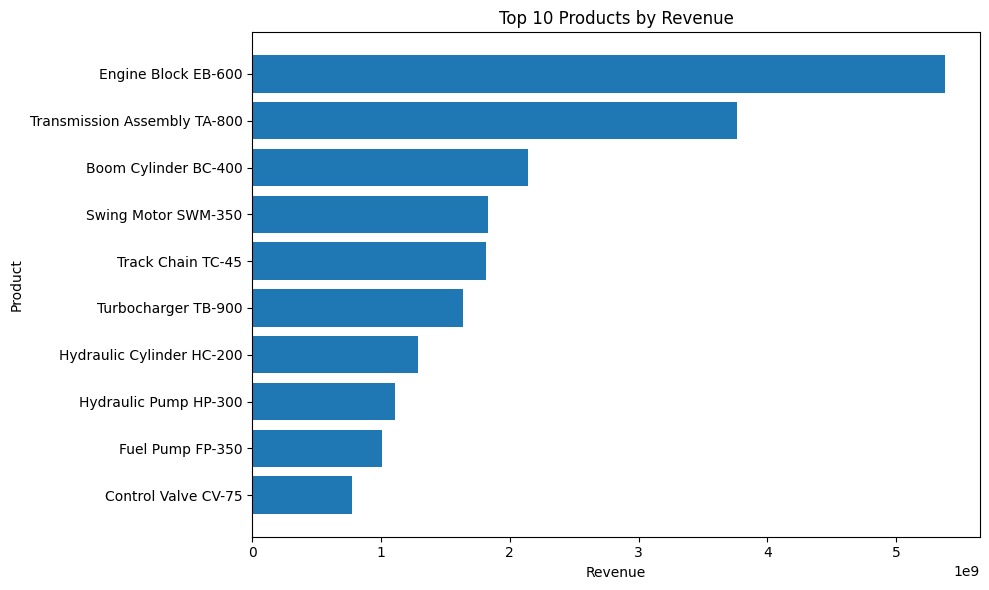

In [42]:
top10 = (
    product_performance
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["product_name"].astype(str),
    top10["total_revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")

plt.tight_layout()
plt.show()

### **Top Products by Units Sold**

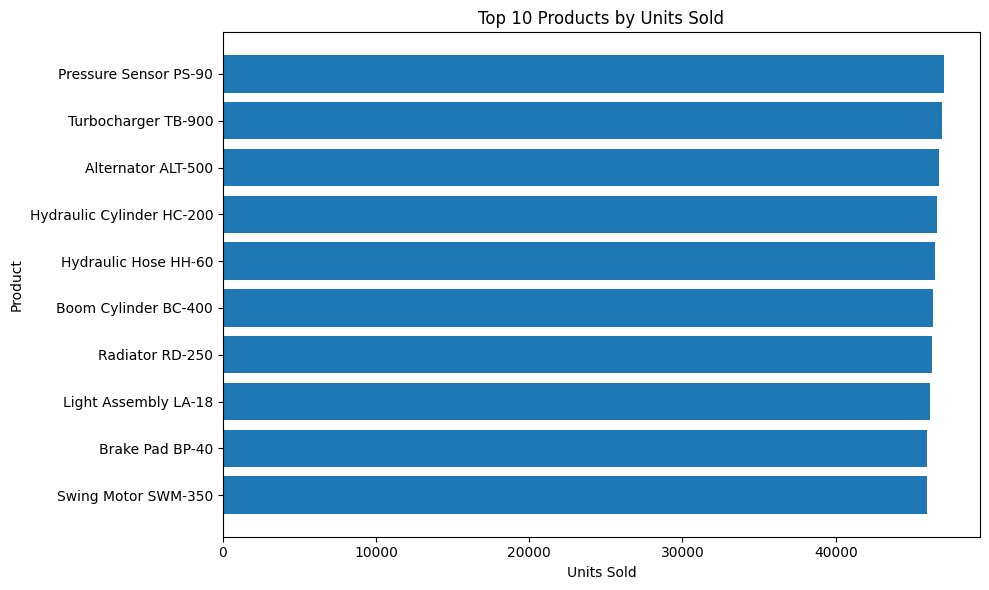

In [43]:
top10_units = (
    product_performance
    .sort_values("total_units_sold", ascending=False)
    .head(10)
    .sort_values("total_units_sold")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_units["product_name"].astype(str),
    top10_units["total_units_sold"]
)

plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.title("Top 10 Products by Units Sold")

plt.tight_layout()
plt.show()

### **Warehouse Revenue**

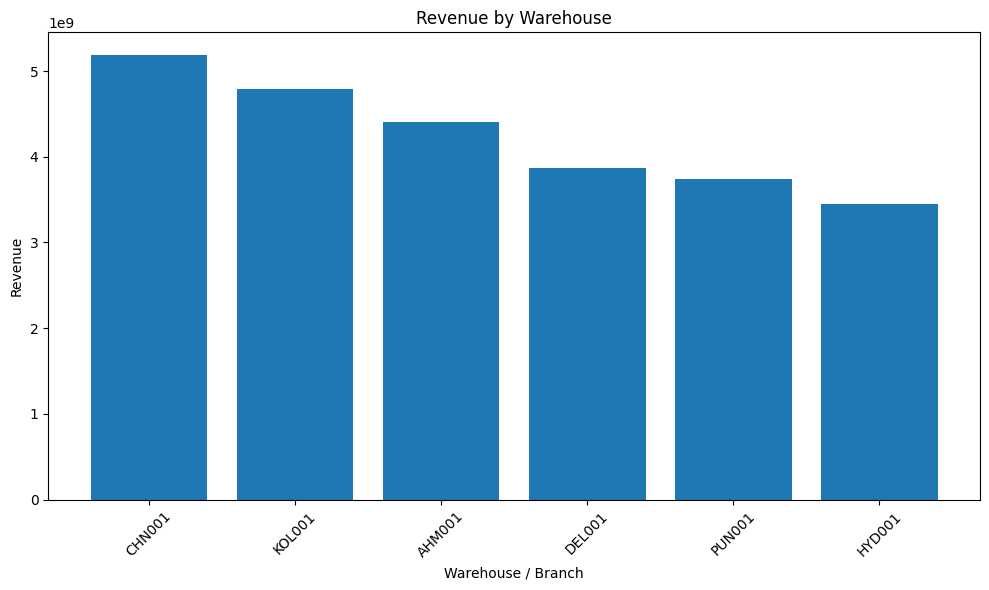

In [44]:
plot_data = warehouse_performance.sort_values(
    "total_revenue",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["branch_id"].astype(str),
    plot_data["total_revenue"]
)

plt.xlabel("Warehouse / Branch")
plt.ylabel("Revenue")
plt.title("Revenue by Warehouse")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Warehouse Units**

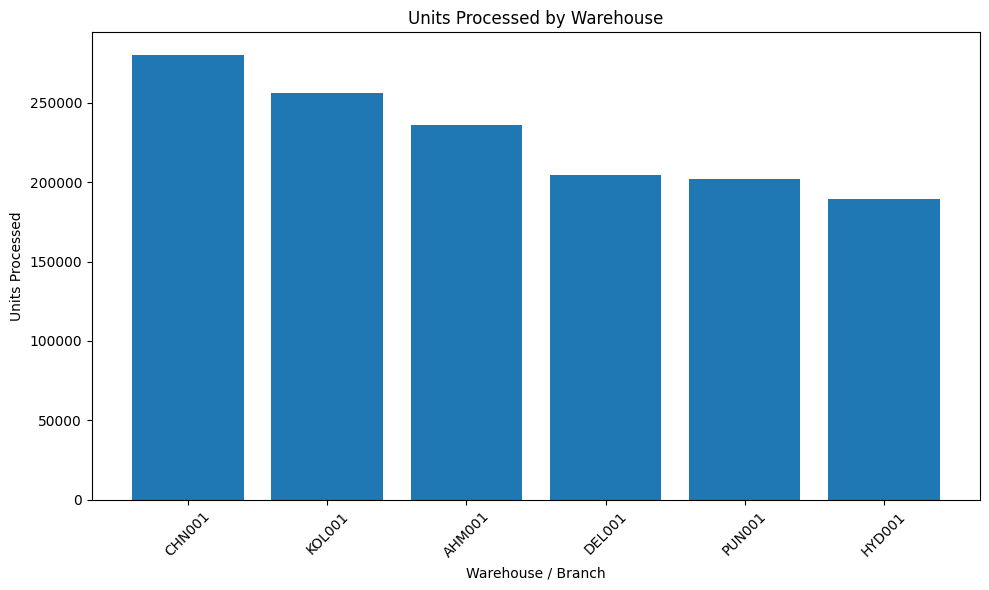

In [45]:
plot_data = warehouse_performance.sort_values(
    "total_units",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["branch_id"].astype(str),
    plot_data["total_units"]
)

plt.xlabel("Warehouse / Branch")
plt.ylabel("Units Processed")
plt.title("Units Processed by Warehouse")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Warehouse Performance Score**

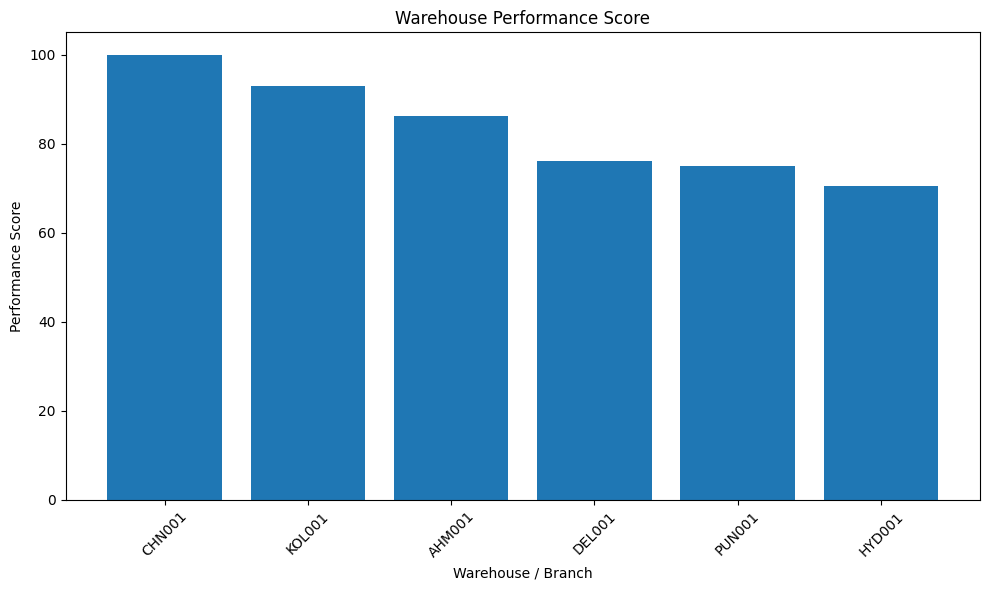

In [46]:
plot_data = warehouse_performance.sort_values(
    "warehouse_performance_score",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["branch_id"].astype(str),
    plot_data["warehouse_performance_score"]
)

plt.xlabel("Warehouse / Branch")
plt.ylabel("Performance Score")
plt.title("Warehouse Performance Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Product Performance Score**

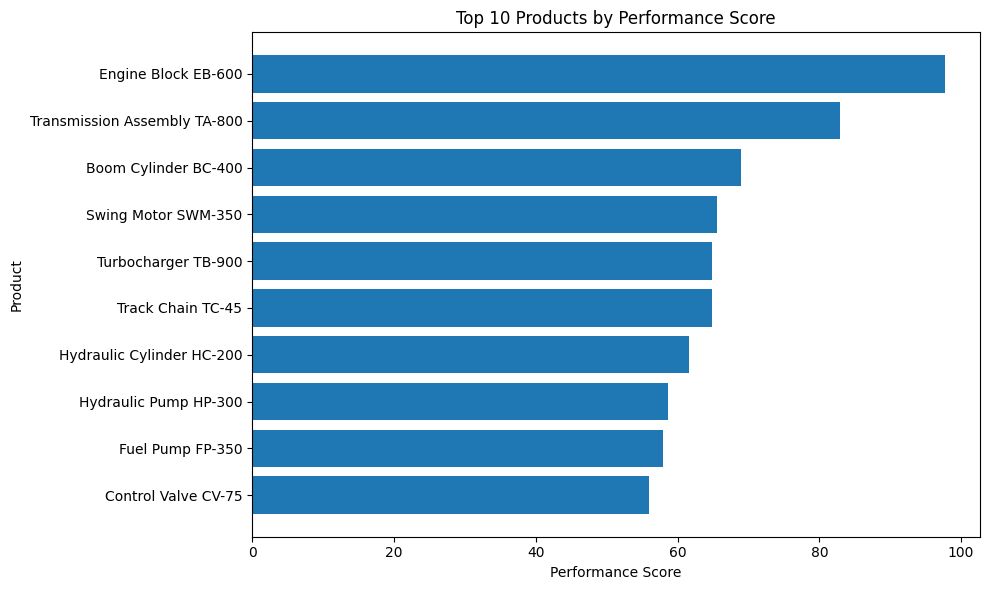

In [47]:
top10_score = (
    product_performance
    .sort_values(
        "product_performance_score",
        ascending=False
    )
    .head(10)
    .sort_values("product_performance_score")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_score["product_name"].astype(str),
    top10_score["product_performance_score"]
)

plt.xlabel("Performance Score")
plt.ylabel("Product")
plt.title("Top 10 Products by Performance Score")

plt.tight_layout()
plt.show()

### **BUSINESS INVESTIGATION**

### **Identify High-Performing Products**

In [54]:
high_performing_products = (
    product_performance[
        product_performance["performance_category"]
        == "High Performance"
    ]
    .sort_values(
        "product_performance_score",
        ascending=False
    )
)

high_performing_products

,product_id,product_name,total_units_sold,total_revenue,total_orders,warehouses_served,customers_served,average_revenue_per_order,revenue_share_percentage,unit_share_percentage,revenue_score,unit_score,order_score,product_performance_score,performance_category
14,P015,Engine Block EB-600,45222,5381418000,3773,6,499,1.426297e+06,21.147228,3.304412,100.000000,96.082097,94.751381,97.774905,High Performance
13,P014,Transmission Assembly TA-800,45035,3760422500,3838,6,500,9.797870e+05,14.777241,3.290748,69.877911,95.684783,96.383727,82.921136,High Performance
20,P021,Boom Cylinder BC-400,46364,2142016800,3873,6,500,5.530640e+05,8.417431,3.387859,39.803948,98.508477,97.262682,68.907053,High Performance
18,P019,Swing Motor SWM-350,45971,1829645800,3849,6,499,4.753561e+05,7.189915,3.359142,33.999325,97.673480,96.659970,65.633700,High Performance
9,P010,Turbocharger TB-900,46964,1639043600,3933,6,500,4.167413e+05,6.440910,3.431701,30.457467,99.783283,98.769463,64.917611,High Performance
3,P004,Track Chain TC-45,45575,1813885000,3781,6,500,4.797368e+05,7.127980,3.330206,33.706451,96.832108,94.952285,64.893315,High Performance
10,P011,Hydraulic Cylinder HC-200,46612,1286491200,3982,6,500,3.230766e+05,5.055493,3.405980,23.906175,99.035397,100.000000,61.663707,High Performance
0,P001,Hydraulic Pump HP-300,45389,1112030500,3854,6,500,2.885393e+05,4.369919,3.316615,20.664265,96.436918,96.785535,58.620315,High Performance


### **Identify Low-Performing Products**

In [55]:
low_performing_products = (
    product_performance[
        product_performance["performance_category"]
        == "Low Performance"
    ]
    .sort_values(
        "product_performance_score"
    )
)

low_performing_products

,product_id,product_name,total_units_sold,total_revenue,total_orders,warehouses_served,customers_served,average_revenue_per_order,revenue_share_percentage,unit_share_percentage,revenue_score,unit_score,order_score,product_performance_score,performance_category
12,P013,Seal Kit SK-15,44081,63917450,3783,6,499,16895.968808,0.251175,3.221038,1.187744,93.657842,95.002511,47.691727,Low Performance
25,P026,Grease Cartridge GC-5,44844,13901640,3823,6,500,3636.317029,0.054629,3.276791,0.258327,95.278970,96.007032,47.914261,Low Performance
7,P008,Bucket Tooth BT-10,45376,26318080,3860,6,500,6818.155440,0.103422,3.315665,0.489055,96.409298,96.936213,48.554559,Low Performance
19,P020,Pivot Pin PP-12,45340,52141000,3823,6,500,13638.765368,0.204897,3.313034,0.968908,96.332809,96.007032,48.585703,Low Performance
1,P002,Engine Oil Filter OF-90,45342,32646240,3861,6,500,8455.384615,0.128289,3.313180,0.606648,96.337059,96.961326,48.596707,Low Performance
26,P027,O-Ring Set OR-50,45678,21925440,3860,6,500,5680.165803,0.086160,3.337732,0.407429,97.050950,96.936213,48.706242,Low Performance
16,P017,Fan Belt FB-30,45578,23700560,3913,6,500,6056.877076,0.093136,3.330425,0.440415,96.838482,98.267202,48.925193,Low Performance
2,P003,Air Filter AF-120,45684,57105000,3895,6,500,14661.103979,0.224404,3.338171,1.061152,97.063698,97.815168,49.212719,Low Performance


### **Identify High-Performing Warehouses**

In [60]:
high_performing_warehouses = (
    warehouse_performance[
        warehouse_performance["performance_category"]
        == "High Performance"
    ]
    .sort_values(
        "warehouse_performance_score",
        ascending=False
    )
)

high_performing_warehouses

,branch_id,total_orders,total_units,total_revenue,products_handled,customers_served,average_order_value,average_units_per_order,revenue_share_percentage,revenue_score,order_score,unit_score,product_variety_score,warehouse_performance_score,performance_category
1,CHN001,4067,280446,5192125100,30,102,1.276647e+06,68.956479,20.403368,100.000000,100.000000,100.000000,100.0,100.000000,High Performance
4,KOL001,3794,256095,4787656160,30,96,1.261902e+06,67.500000,18.813936,92.209954,93.287435,91.317045,100.0,93.035102,High Performance


### **Identify Low-Performing Warehouses**

In [61]:
low_performing_warehouses = (
    warehouse_performance[
        warehouse_performance["performance_category"]
        == "Low Performance"
    ]
    .sort_values(
        "warehouse_performance_score"
    )
)

low_performing_warehouses

,branch_id,total_orders,total_units,total_revenue,products_handled,customers_served,average_order_value,average_units_per_order,revenue_share_percentage,revenue_score,order_score,unit_score,product_variety_score,warehouse_performance_score,performance_category
3,HYD001,2768,189163,3452672510,30,68,1.247353e+06,68.339234,13.567883,66.498253,68.059995,67.450775,100.0,70.476994,Low Performance
5,PUN001,2972,201749,3741098180,30,75,1.258781e+06,67.883244,14.701303,72.053314,73.075977,71.938626,100.0,75.074976,Low Performance


### **Final KPIs**

In [62]:
week7_kpis = {
    "Total Products Analysed": product_performance["product_id"].nunique(),
    "Total Warehouses/Branches": warehouse_performance["branch_id"].nunique(),
    "Total Units Sold": week7_data["quantity"].sum(),
    "Total Revenue": week7_data["line_total"].sum(),
    "Average Revenue per Product": product_performance["total_revenue"].mean(),
    "Average Products per Warehouse": warehouse_performance["products_handled"].mean(),
    "Average Warehouse Performance Score": warehouse_performance["warehouse_performance_score"].mean(),
    "Average Product Performance Score": product_performance["product_performance_score"].mean(),
    "High-Performing Products": (
        product_performance["performance_category"]
        .eq("High Performance")
        .sum()
    ),
    "High-Performing Warehouses": (
        warehouse_performance["performance_category"]
        .eq("High Performance")
        .sum()
    )
}

week7_kpis

{'Total Products Analysed': 30,
 'Total Warehouses/Branches': 6,
 'Total Units Sold': np.int64(1368534),
 'Total Revenue': np.int64(25447392560),
 'Average Revenue per Product': np.float64(848246418.6666666),
 'Average Products per Warehouse': np.float64(30.0),
 'Average Warehouse Performance Score': np.float64(83.49717036538983),
 'Average Product Performance Score': np.float64(56.3351970150277),
 'High-Performing Products': np.int64(8),
 'High-Performing Warehouses': np.int64(2)}

### **Create KPI DataFrame**

In [63]:
week7_kpi_table = pd.DataFrame(
    list(week7_kpis.items()),
    columns=["KPI", "Value"]
)

week7_kpi_table

,KPI,Value
0,Total Products Analysed,3.000000e+01
1,Total Warehouses/Branches,6.000000e+00
2,Total Units Sold,1.368534e+06
3,Total Revenue,2.544739e+10
4,Average Revenue per Product,8.482464e+08
5,Average Products per Warehouse,3.000000e+01
6,Average Warehouse Performance Score,8.349717e+01
7,Average Product Performance Score,5.633520e+01
8,High-Performing Products,8.000000e+00
9,High-Performing Warehouses,2.000000e+00


### **Format KPI Values**

In [64]:
formatted_kpis = week7_kpi_table.copy()

for i, row in formatted_kpis.iterrows():
    if "Revenue" in row["KPI"]:
        formatted_kpis.loc[i, "Value"] = (
            f"£{row['Value']:,.2f}"
        )
    elif "Score" in row["KPI"]:
        formatted_kpis.loc[i, "Value"] = (
            f"{row['Value']:.2f}"
        )
    elif isinstance(row["Value"], (int, np.integer)):
        formatted_kpis.loc[i, "Value"] = (
            f"{row['Value']:,}"
        )

formatted_kpis

/tmp/ipykernel_3346/2832924969.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '£25,447,392,560.00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_kpis.loc[i, "Value"] = (


,KPI,Value
0,Total Products Analysed,30.0
1,Total Warehouses/Branches,6.0
2,Total Units Sold,1368534.0
3,Total Revenue,"£25,447,392,560.00"
4,Average Revenue per Product,"£848,246,418.67"
5,Average Products per Warehouse,30.0
6,Average Warehouse Performance Score,83.50
7,Average Product Performance Score,56.34
8,High-Performing Products,8.0
9,High-Performing Warehouses,2.0


### **Create Output Folders**

In [65]:
analysis_dir = Path("../analysis")

analysis_dir.mkdir(parents=True, exist_ok=True)
visual_dir.mkdir(parents=True, exist_ok=True)

### **Save Product Performance**

In [66]:
product_performance.to_csv(
    analysis_dir / "product_performance.csv",
    index=False
)

### **Save Warehouse Performance**

In [67]:
warehouse_performance.to_csv(
    analysis_dir / "warehouse_performance.csv",
    index=False
)

### **Save Product–Warehouse Analysis**

In [68]:
product_warehouse.to_csv(
    analysis_dir / "product_warehouse_alignment.csv",
    index=False
)

### **Save Product Distribution**

In [69]:
product_distribution.to_csv(
    analysis_dir / "product_warehouse_distribution.csv",
    index=False
)

### **Save KPI Results**

In [70]:
week7_kpi_table.to_csv(
    analysis_dir / "week7_performance_kpis.csv",
    index=False
)

### **Final Summary**

In [71]:
print("=" * 60)
print("WEEK 07 — PRODUCT–WAREHOUSE ALIGNMENT & PERFORMANCE")
print("=" * 60)

print(f"Products analysed: {product_performance['product_id'].nunique():,}")
print(f"Warehouses/branches: {warehouse_performance['branch_id'].nunique():,}")
print(f"Total units sold: {week7_data['quantity'].sum():,.0f}")
print(f"Total revenue: £{week7_data['line_total'].sum():,.2f}")

print(
    f"Average product performance score: "
    f"{product_performance['product_performance_score'].mean():.2f}"
)

print(
    f"Average warehouse performance score: "
    f"{warehouse_performance['warehouse_performance_score'].mean():.2f}"
)

print(
    f"High-performing products: "
    f"{(product_performance['performance_category'] == 'High Performance').sum():,}"
)

print(
    f"High-performing warehouses: "
    f"{(warehouse_performance['performance_category'] == 'High Performance').sum():,}"
)

print("=" * 60)
print("Week 07 analysis completed.")

WEEK 07 — PRODUCT–WAREHOUSE ALIGNMENT & PERFORMANCE
Products analysed: 30
Warehouses/branches: 6
Total units sold: 1,368,534
Total revenue: £25,447,392,560.00
Average product performance score: 56.34
Average warehouse performance score: 83.50
High-performing products: 8
High-performing warehouses: 2
Week 07 analysis completed.
